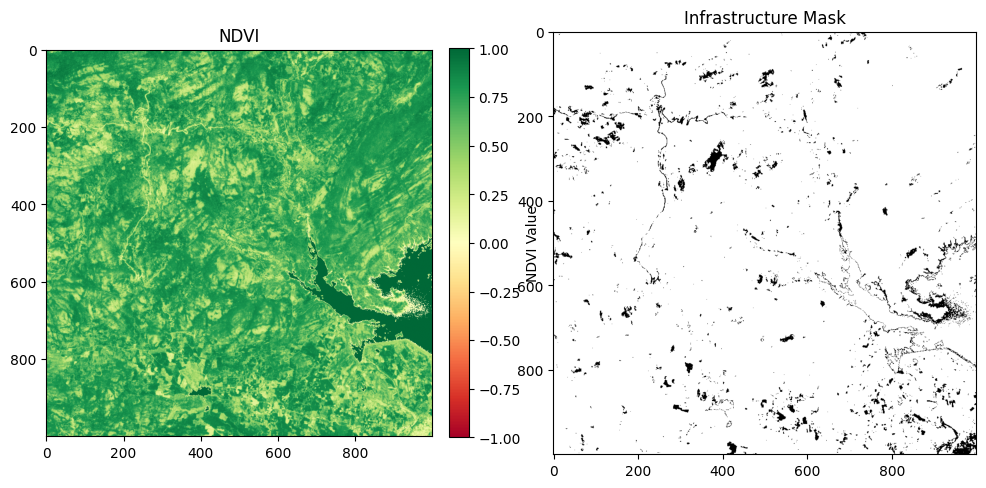

In [2]:
import rasterio 
from rasterio.windows import Window
import numpy as np 
import matplotlib.pyplot as plt

red = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B04_10m.jp2"
nir = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B08_10m.jp2"

window = Window(0,0,1000,1000)
with rasterio.open(red) as red_src , rasterio.open(nir) as nir_src:
    raw_red = red_src.read(1,window = window)
    raw_nir = nir_src.read(1,window=window)

    stack=[raw_red,raw_nir]
    for i in range(2):
        haze = np.min(stack[i][stack[i]>0])
        corrected = stack[i] - haze
        stack[i]=corrected
    
    ndvi = (stack[1]-stack[0])/(stack[1]+stack[0]+1e-10)
    infrastructure_mask = (ndvi > 0.01) & (ndvi < 0.3)



    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,6))
    im1 = ax1.imshow(ndvi,cmap='RdYlGn',vmin=-1,vmax=1)
    ax1.set_title("NDVI")
    cbar1=fig.colorbar(im1,ax=ax1,fraction=0.046, pad=0.04)
    cbar1.set_label('NDVI Value')

    ax2.imshow(infrastructure_mask,cmap='binary')
    ax2.set_title("Infrastructure Mask")
    plt.show()


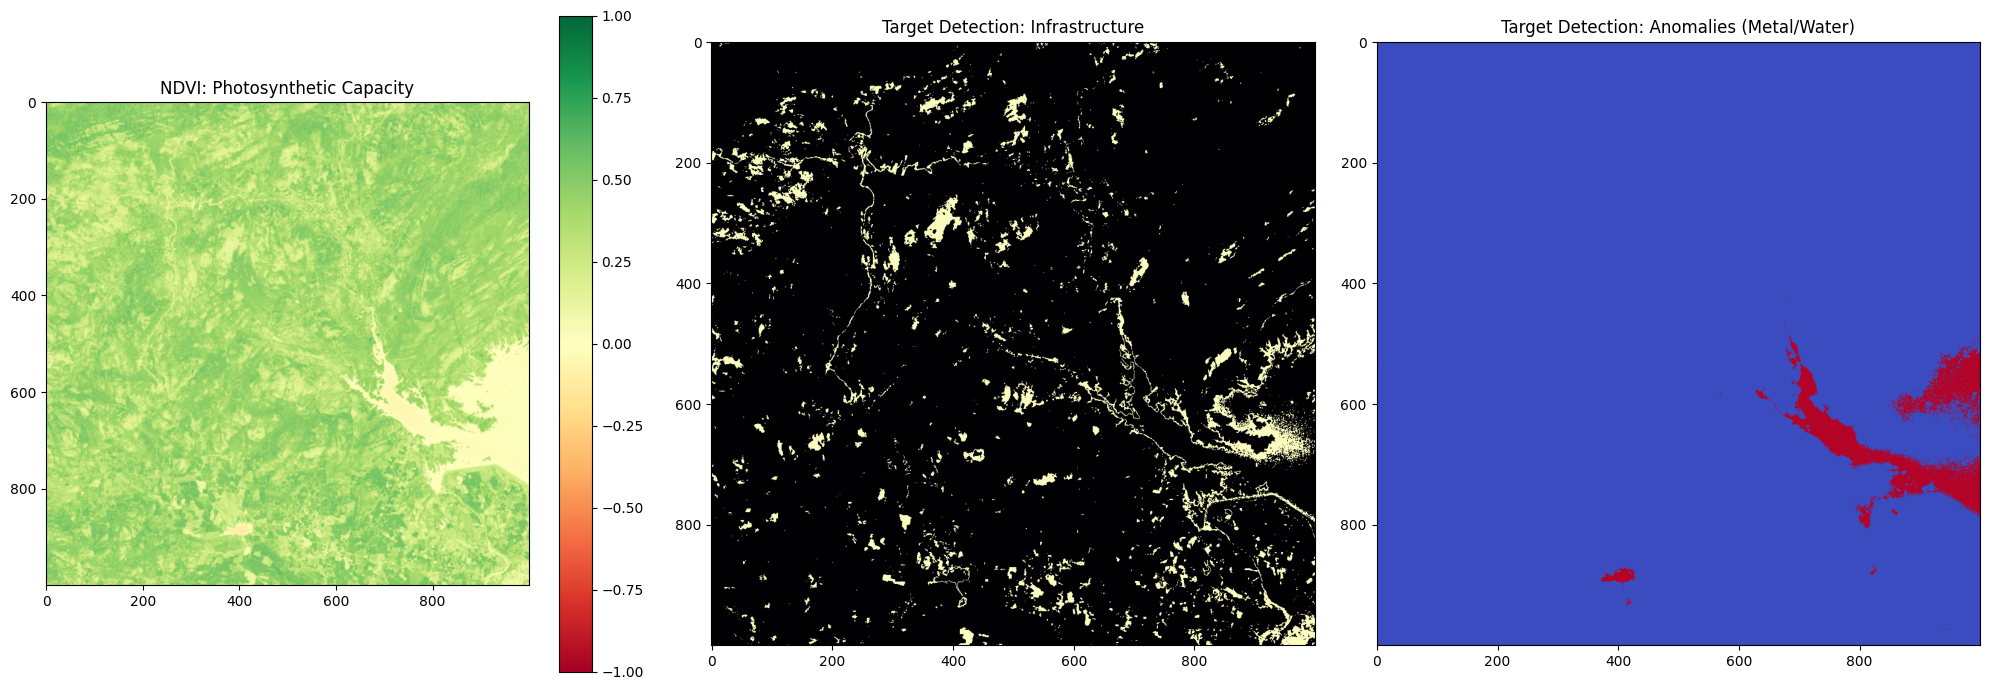

Intelligence Summary:
Average Vegetation Index: 0.36
Detected Infrastructure Pixels: 64135
Detected Anomaly Pixels: 26346


In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.windows import Window

# 1. Load your co-registered bands (B04=Red, B08=NIR)
# Replace with your actual file paths
red_path = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B04_10m.jp2"
nir_path = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B08_10m.jp2"

# Process a 1km x 1km patch for testing
my_window = Window(0, 0, 1000, 1000)

with rasterio.open(red_path) as red_src, rasterio.open(nir_path) as nir_src:
    # Read and normalize to 0.0 - 1.0 range
    red = red_src.read(1, window=my_window).astype('float32') / 10000
    nir = nir_src.read(1, window=my_window).astype('float32') / 10000

# 2. THE PhD FORMULA (Claim 1 Implementation)
# We add a tiny epsilon (1e-10) to the denominator to prevent onboard CPU crashes
# This ensures stability during graph-traversal and token merging
ndvi = (nir - red) / (nir + red + 1e-10)

# 3. DEFENSE INTELLIGENCE MASKS (Feature Engineering)
# Mask 1: Infrastructure (Bare soil, concrete, clearings)
# Logic: These show very low but positive NDVI (0.01 - 0.2)
infra_mask = (ndvi > 0.01) & (ndvi < 0.2)

# Mask 2: Water or Metal (The Anomalous Zone)
# Logic: NIR absorption or specular reflection leads to negative values
anomaly_mask = (ndvi < 0)

# 4. VISUALIZATION
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

# Plot NDVI Map
im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
ax1.set_title("NDVI: Photosynthetic Capacity")
plt.colorbar(im1, ax=ax1)

# Plot Infrastructure Targets (Potential Buildings/Roads)
ax2.imshow(infra_mask, cmap='magma')
ax2.set_title("Target Detection: Infrastructure")

# Plot Anomalies (Potential Water/Metallic Objects)
ax3.imshow(anomaly_mask, cmap='coolwarm')
ax3.set_title("Target Detection: Anomalies (Metal/Water)")

plt.tight_layout()
plt.show()

# 5. DATA LOG (For Claim 10ii: Natural Language Report)
print(f"Intelligence Summary:")
print(f"Average Vegetation Index: {np.mean(ndvi):.2f}")
print(f"Detected Infrastructure Pixels: {np.sum(infra_mask)}")
print(f"Detected Anomaly Pixels: {np.sum(anomaly_mask)}")

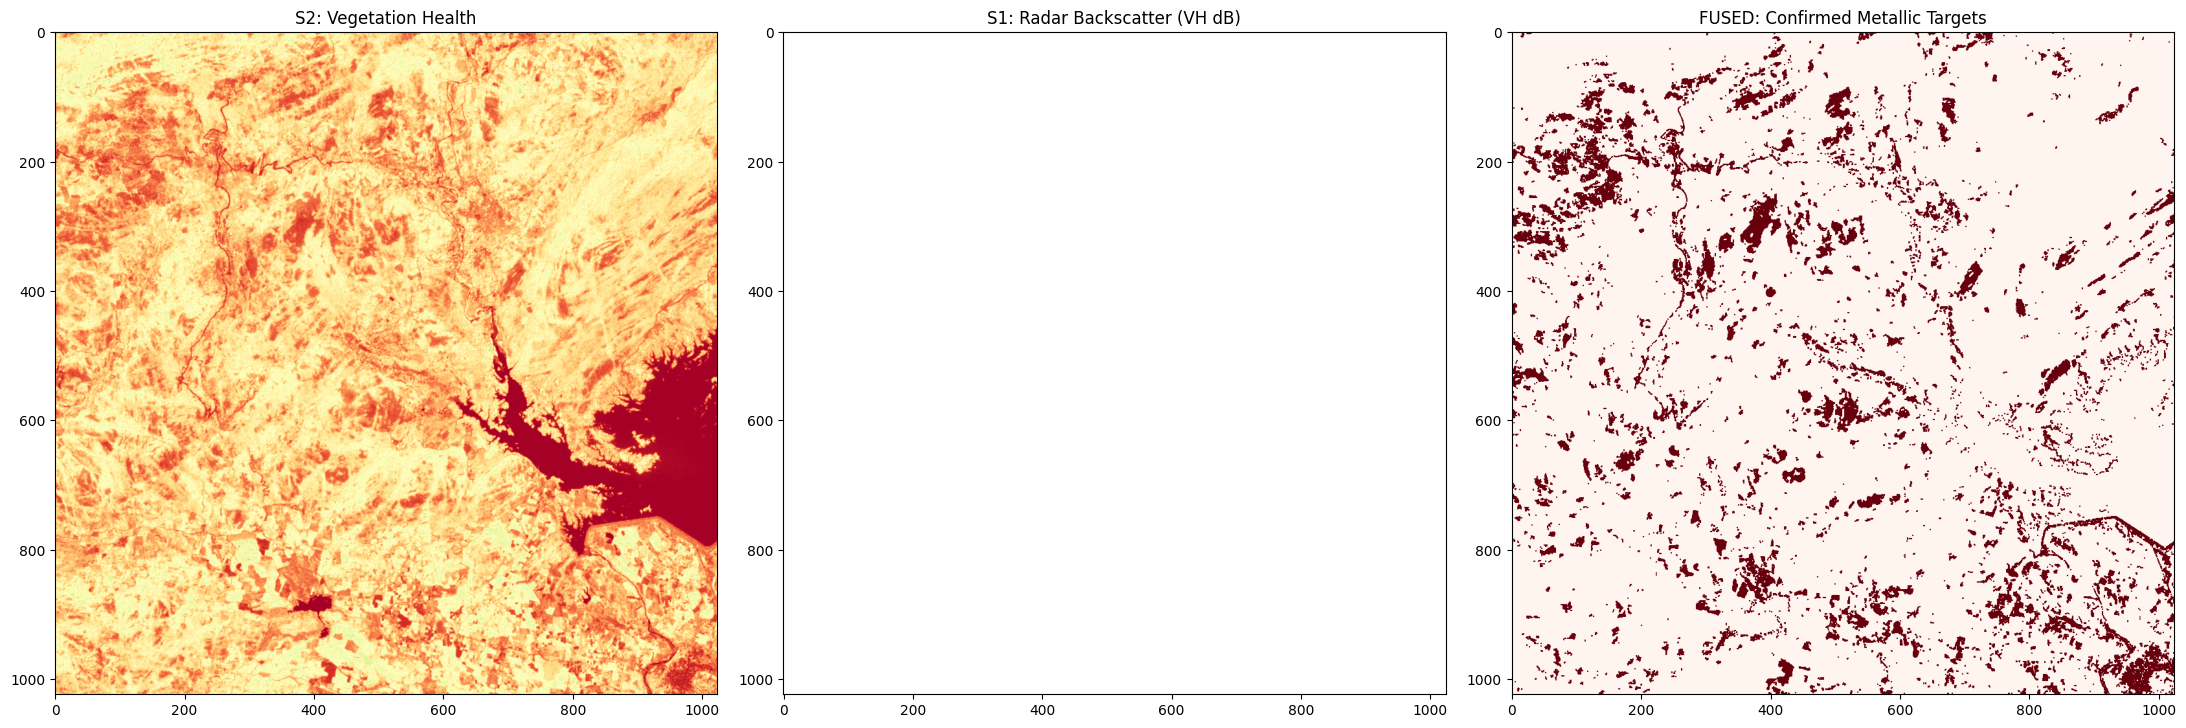

Intelligence Summary: 115298 target pixels detected.


In [26]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.windows import Window

# --- 1. SETUP PATHS ---
red_path = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B04_10m.jp2"
nir_path = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B08_10m.jp2"
sar_vh_path = r"C:\Users\hsgpi\OneDrive\Desktop\sem4\S1A_IW_GRDH_1SDV_20260206T002220_20260206T002245_063091_07EB16_F329\S1A_IW_GRDH_1SDV_20260206T002220_20260206T002245_063091_07EB16_F329.SAFE\measurement\s1-vh.tiff" 

my_window = Window(0, 0, 1024, 1024)

# --- 2. OPTICAL PROCESSING ---
with rasterio.open(red_path) as r_src, rasterio.open(nir_path) as n_src:
    red = r_src.read(1, window=my_window).astype('float32')
    nir = n_src.read(1, window=my_window).astype('float32')
    ndvi = (nir - red) / (nir + red + 1e-10)

# --- 3. SAR PROCESSING ---
with rasterio.open(sar_vh_path) as sar_src:
    sar_raw = sar_src.read(1, window=my_window).astype('float32')
    sar_db = 10 * np.log10(sar_raw + 1e-10)

# --- 4. REFINED TARGET CLASSIFICATION (Claim 9 & 13) ---
# Filter A: Not Water, Not Forest (Isolates soil/infrastructure)
is_disturbed = (ndvi > 0.05) & (ndvi < 0.25) 

# Filter B: High-Energy Metallic Return (Stricter threshold to kill water noise)
is_metallic = (sar_db > -6) 

# Fusion: Initial Mask
raw_targets = (is_disturbed & is_metallic).astype(np.uint8)

# --- 5. HARDWARE-STYLE NOISE CLEANING (Claim 12) ---
# We use a 2x2 "Filter" to remove any red dot that doesn't have neighbors.
# Real metal objects are usually larger than 1 pixel (10m x 10m).
confirmed_targets = np.zeros_like(raw_targets)
for i in range(raw_targets.shape[0]-1):
    for j in range(raw_targets.shape[1]-1):
        # If a 2x2 block is all 1s, keep it. This removes 'speckle'.
        if np.sum(raw_targets[i:i+2, j:j+2]) == 4:
            confirmed_targets[i:i+2, j:j+2] = 1

# --- 6. VISUALIZATION ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

ax1.imshow(ndvi, cmap='RdYlGn', vmin=0, vmax=1)
ax1.set_title("S2: Vegetation Health")

ax2.imshow(sar_db, cmap='gray', vmin=-25, vmax=0)
ax2.set_title("S1: Radar Backscatter (VH dB)")

ax3.imshow(confirmed_targets, cmap='Reds')
ax3.set_title("FUSED: Confirmed Metallic Targets")

plt.tight_layout()
plt.show()

print(f"Intelligence Summary: {np.sum(confirmed_targets)} target pixels detected.")